# 01_回归算法-贝叶斯回归

## Notebook 使用说明

建议先阅读理论，再从上到下运行全部单元；使用 Python 3.11–3.13 内核。数据与辅助模块均来自本文件夹，安装依赖后无需联网获取案例数据。

本篇数据：`dataset/BostonHousing.csv`。

转写调整：

- 修复或适配代码；原讲解性输出保留为 Markdown，Python 单元按顺序执行。

原文参考图及静态数值仅用于对照；重跑后的代码输出为本次实验结果。依赖版本与验证记录见根目录 `README.md` 和 `reports/`。

In [1]:
# 从当前目录向上寻找本套 Notebook 的根目录，移动整个文件夹后仍可运行。
from pathlib import Path
import os, sys, tempfile, random
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "notebook_support.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("请从这套 Notebook 文件夹内启动 Jupyter，并保留 notebook_support.py。")
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))
from notebook_support import DATA_DIR, load_local_housing, load_local_boston, load_local_mnist, load_creditcard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
random.seed(42)
np.random.seed(42)
# 按实际安装的字体选择，兼容 macOS / Windows / Linux。
_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei", "SimHei", "Noto Sans CJK SC"]
             if f in _available_fonts] + ["DejaVu Sans"]
plt.rcParams.update({"font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
                     "figure.dpi": 90, "figure.max_open_warning": 30})
%matplotlib inline


今天咱们来聊聊：贝叶斯回归，用概率思维来做预测。

先来点直觉理解，假设你想预测一个人的身高，你已经知道他是一个成年男性。

- **普通回归**：可能会直接给出一个固定的预测值，比如175cm。
- **贝叶斯回归**：不会给你一个死板的答案，而是会告诉你“这个人的身高**大概率**在170\~180cm之间，但也有**小概率**低于170cm或高于180cm”。

换句话说，贝叶斯回归不仅告诉你预测的结果，还告诉你对这个预测有多大的信心（即不确定性）。

#### 贝叶斯回归的核心思想

贝叶斯回归的核心就是**贝叶斯定理**，这个定理的意思是：

> **用已有的知识（先验）+ 新的数据（证据），来更新我们的信念（后验）**

比如：

- 你一开始认为成年男性的身高大致在170\~180cm之间（**先验知识**）。
- 但你看到这个人平时穿加长裤，站在人群中明显比别人高（**新数据**）。
- 于是你调整你的预测，认为他更有可能接近185cm（**后验概率**）。

这个不断调整的过程就是贝叶斯回归的核心。

#### 贝叶斯回归 vs 经典回归

| 特点 | 经典回归（最小二乘法） | 贝叶斯回归 |
|-|-|-|
| **结果** | 一个固定的数值（比如175cm） | 一个概率分布（比如大多数在170\~180cm之间） |
| **不确定性** | 不提供 | 提供预测的可信度 |
| **数据量要求** | 需要大量数据训练 | 适合数据少的情况（因为可以利用“先验”） |
| **适应性** | 一旦训练完成，模型固定 | 可以随着新数据不断更新预测 |

#### 什么时候用贝叶斯回归？

- **数据很少**：比如你只有10个人的身高数据，普通回归很难拟合，但贝叶斯回归可以结合先验知识给出更合理的预测。
- **需要不确定性信息**：如果你做的是医疗预测，你不仅想知道病人是否生病，还想知道你的预测有多可靠。
- **动态调整预测**：比如你预测股市走势，每天有新的数据进来，贝叶斯回归可以随着数据变化不断调整模型。

用已有数据来修正我们对参数的信念：

- **贝叶斯回归是一种用概率来做预测的回归方法**，不同于传统回归，它不仅给出一个预测值，还会告诉你预测的置信度。
- **它利用“先验知识 + 数据”来不断更新预测**，特别适用于数据少、需要不确定性分析的情况。
- **它的数学基础是贝叶斯定理**，核心思想是“不断调整信念，使其更符合现实”。

## 原理详解

贝叶斯回归不像经典最小二乘法或最大似然估计（MLE）那样直接求出单一的最优参数，而是通过**概率分布**刻画参数的不确定性。

核心思想是：

> **利用贝叶斯定理，将“先验知识”与“观测数据”结合，从而得到后验分布，并以此进行预测。**

### 1. 贝叶斯回归的数学建模

假设我们有一个线性回归模型：


$$
y = X\beta + \epsilon
$$


其中：

- $y \in \mathbb{R}^{n \times 1}$是目标变量（观测数据）。
- $X \in \mathbb{R}^{n \times d}$是特征矩阵（自变量）。
- $\beta \in \mathbb{R}^{d \times 1}$是待估计的参数。

$\epsilon \sim \mathcal{N}(0, \sigma^2 I)$是噪声项，假设服从均值为 0、方差为 $\sigma^2$的正态分布。

对于传统的最小二乘回归，我们通常直接求解参数 $\beta$使得误差最小。

但在贝叶斯回归中，我们认为 $\beta$**不是一个固定值，而是一个概率分布**。

### 2. 贝叶斯回归的推导

#### 先验分布（Prior Distribution）

在贝叶斯统计中，我们在数据观测之前就可以对参数 $\beta$施加先验分布，表示我们对其的初始假设。最常见的选择是

**高斯分布**：  
$p(\beta) = \mathcal{N}(\beta | \mu_0, \Sigma_0)$  
其中：

$\mu_0$是 $\beta$的先验均值（通常取 0）。

$\Sigma_0$是 $\beta$的先验协方差矩阵，表示参数的初始不确定性。

这样，我们假设参数 $\beta$服从一个先验正态分布，它的分布特征由 $\mu_0$和 $\Sigma_0$控制。

#### 似然函数（Likelihood Function）

数据 $(X, y)$服从线性模型：


$$
y = X\beta + \epsilon, \quad \epsilon \sim \mathcal{N}(0, \sigma^2 I)
$$


因此，给定 $\beta$时，目标变量 $y$服从以下正态分布：


$$
p(y | X, \beta) = \mathcal{N}(y | X\beta, \sigma^2 I)
$$


这个概率表示**在给定** $\beta$**的情况下，我们如何生成数据** $y$，即数据的“似然”（Likelihood）。

#### 后验分布（Posterior Distribution）

贝叶斯定理告诉我们，后验分布可以由先验分布与似然函数通过**贝叶斯公式**计算：


$$
p(\beta | X, y) = \frac{p(y | X, \beta) p(\beta)}{p(y | X)}
$$


其中：

- $p(\beta)$是**先验**，表示我们在看到数据前对 $\beta$的认知。
- $p(y | X, \beta)$是**似然**，表示给定 $\beta$时，数据 $y$的概率。
- $p(y | X)$是归一化项，与 $\beta$无关，一般不直接计算。

由于 $p(\beta)$和 $p(y | X, \beta)$都是高斯分布，根据**高斯分布的共轭性质**，后验分布 $p(\beta | X, y)$仍然是一个高斯分布：  
$p(\beta | X, y) = \mathcal{N}(\beta | \mu_n, \Sigma_n)$  
其中：

- **后验均值**：  
$\mu_n = \Sigma_n \left( \Sigma_0^{-1} \mu_0 + \frac{1}{\sigma^2} X^T y \right)$
- **后验协方差**：  
$\Sigma_n = \left( \Sigma_0^{-1} + \frac{1}{\sigma^2} X^T X \right)^{-1}$

这个公式的含义是：

- **后验均值** $\mu_n$：由先验信息和数据贡献共同决定。
- **后验协方差** $\Sigma_n$：当数据量增多时，参数的不确定性减少，即协方差变小。

### 3. 预测分布

在贝叶斯回归中，我们不仅关注参数 $\beta$的后验分布，还关心新输入数据 $x_*$时的预测输出 $y_*$的分布。

给定新数据 $x_*$，其预测值 $y_*$的分布为：


$$
p(y_* | x_*, X, y) = \int p(y_* | x_*, \beta) p(\beta | X, y) d\beta
$$


因为 $p(\beta | X, y)$和 $p(y_* | x_*, \beta)$都是高斯分布，它们的**加权积分仍然是高斯分布**：


$$
p(y_* | x_*, X, y) = \mathcal{N}(y_* | x_*^T \mu_n, x_*^T \Sigma_n x_* + \sigma^2)
$$


即：

- 预测均值：$\mathbb{E}[y_*] = x_*^T \mu_n$
- 预测方差：$\text{Var}(y_*) = x_*^T \Sigma_n x_* + \sigma^2$

这个结果告诉我们，贝叶斯回归不仅能给出预测值 $x_*^T \mu_n$，还能给出预测的不确定性 $x_*^T \Sigma_n x_* + \sigma^2$。

### 4. 贝叶斯回归的算法流程

总结贝叶斯回归的计算步骤如下：

#### 1）设定先验分布

设定参数 $\beta$的先验分布：


$$
p(\beta) = \mathcal{N}(\beta | \mu_0, \Sigma_0)
$$


通常 $\mu_0 = 0, \Sigma_0 = I \sigma_0^2$。

#### 2）计算后验分布

使用数据 $(X, y)$更新 $\beta$的后验分布：  
$\mu_n = \Sigma_n \left( \Sigma_0^{-1} \mu_0 + \frac{1}{\sigma^2} X^T y \right)$  
$\Sigma_n = \left( \Sigma_0^{-1} + \frac{1}{\sigma^2} X^T X \right)^{-1}$

#### 3）计算预测分布

给定新输入 $x_*$，计算预测均值和方差：


$$
\mathbb{E}[y_*] = x_*^T \mu_n
$$


$$
\text{Var}(y_*) = x_*^T \Sigma_n x_* + \sigma^2
$$


## 完整案例

使用贝叶斯回归对**房价预测**进行建模，数据集来自 **sklearn** 的 **Boston Housing Dataset**（波士顿房价数据）。

1. **数据预处理**：对数据进行标准化，并拆分训练集和测试集。
2. **贝叶斯回归建模**：使用 **sklearn** 的 **BayesianRidge** 进行建模。
3. **预测分析**：对测试数据进行预测，并分析模型性能。
4. **可视化**：

   - 真实值 vs 预测值散点图。
   - 误差分布直方图。
   - 不确定性分析（预测的置信区间）。
5. **算法优化**：调优贝叶斯回归的超参数，提高模型表现。

MSE: 24.427, R^2: 0.667


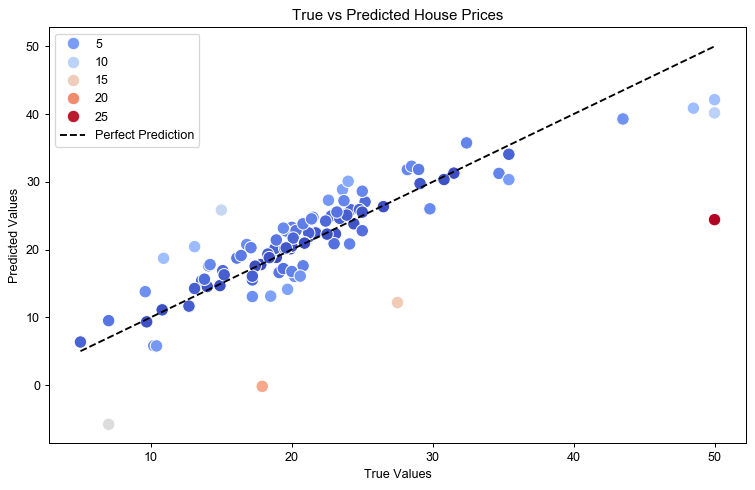

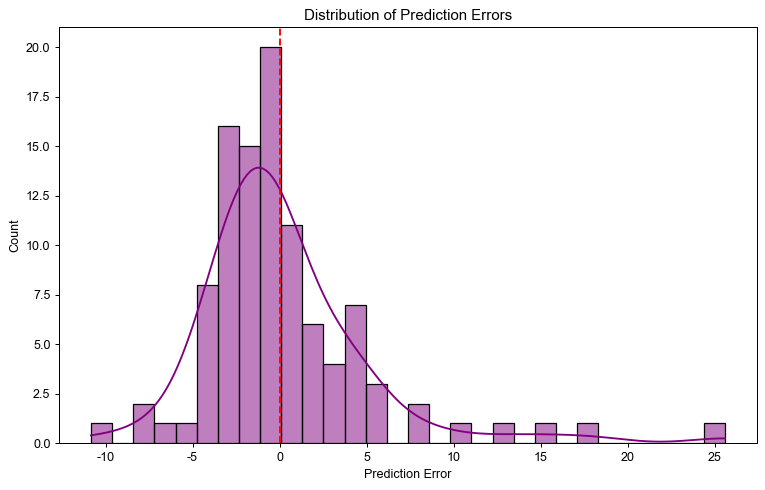

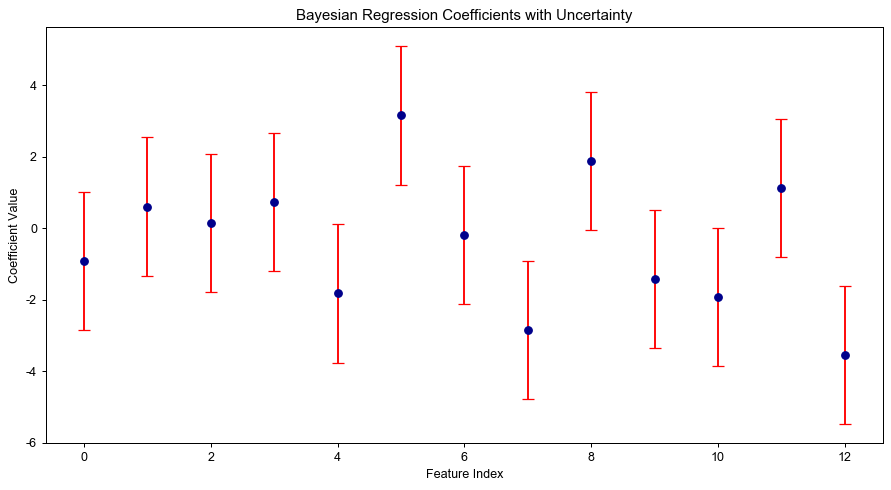

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import BayesianRidge
from sklearn.metrics import mean_squared_error, r2_score
from notebook_support import load_local_boston
# 1. 读取数据
boston = load_local_boston()
X, y = boston.data, boston.target

# 2. 数据标准化 & 拆分训练/测试集
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# 3. 训练贝叶斯回归模型
model = BayesianRidge(tol=1e-6, alpha_1=1e-6, lambda_1=1e-6)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# 4. 计算误差指标
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f'MSE: {mse:.3f}, R^2: {r2:.3f}')

# 5. 预测 vs 真实值 可视化
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred, hue=np.abs(y_test - y_pred), palette='coolwarm', s=100)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], '--k', label='Perfect Prediction')
plt.xlabel('True Values')
plt.ylabel('Predicted Values')
plt.title('True vs Predicted House Prices')
plt.legend()
plt.show()

# 6. 误差分布
plt.figure(figsize=(10, 6))
sns.histplot(y_test - y_pred, kde=True, bins=30, color='purple')
plt.axvline(0, color='red', linestyle='--')
plt.xlabel('Prediction Error')
plt.title('Distribution of Prediction Errors')
plt.show()

# 7. 置信区间可视化
coefs_mean = model.coef_
coefs_std = np.sqrt(1 / model.lambda_)

plt.figure(figsize=(12, 6))
plt.errorbar(range(len(coefs_mean)), coefs_mean, yerr=coefs_std, fmt='o', color='darkblue', ecolor='red', capsize=5)
plt.xlabel('Feature Index')
plt.ylabel('Coefficient Value')
plt.title('Bayesian Regression Coefficients with Uncertainty')
plt.show()

1. **MSE（均方误差）和** $R^2$**（决定系数）**：用于衡量模型的误差和拟合度。
2. **真实值 vs 预测值散点图**：参考线代表完美预测，点越接近参考线，预测效果越好。

![原文参考图，当前结果见代码输出](attachments/img_001.png)

1. **误差分布直方图**：观察误差的集中程度，误差越集中，模型越稳定。

![原文参考图，当前结果见代码输出](attachments/img_002.png)

1. **回归系数的置信区间**：误差棒表示参数的不确定性，红色表示参数变化范围大，说明该变量对预测影响较大。

![原文参考图，当前结果见代码输出](attachments/img_003.png)

#### 算法优化

- **调整 alpha 和 lambda** 以减少过拟合/欠拟合。
- **尝试不同的先验分布（Gaussian Process 变体）** 以增强适应性。
- **特征选择**，减少冗余信息，提高模型稳定性。

## 模型分析

### 贝叶斯回归的优缺点分析

**优点**

1. **提供不确定性估计**：不像普通回归只给出单一预测值，贝叶斯回归还能提供**预测的置信区间**，适用于风险敏感的应用（如金融、医疗）。
2. **适用于小数据集**：在数据量较小时，贝叶斯回归通过**先验分布**可以避免过拟合，而传统回归方法容易因数据不足而表现不稳定。
3. **鲁棒性强**：它引入了正则化（类似于 L2 正则化），在高维特征情况下（特征数远大于样本数）表现更稳定。
4. **动态更新**：可以随着新数据的加入不断调整参数（在线学习），而不需要完全重新训练整个模型。

**缺点**

1. **计算成本较高**：贝叶斯回归需要求解**矩阵的逆**（复杂度 $O(d^3)$），在大规模数据集上计算代价较高。
2. **难以选择合适的先验**：如果先验选择不当，可能会影响最终结果，需要额外的领域知识。
3. **对异常值较敏感**：由于使用了正态分布假设，贝叶斯回归可能会受到异常值的影响，导致预测偏差。

### 贝叶斯回归 vs 其他相似算法

| **算法** | **优点** | **缺点** | **适用场景** |
|-|-|-|-|
| **贝叶斯回归** | 提供不确定性估计，适用于小数据，具有鲁棒性和动态更新能力 | 计算量大，对异常值敏感，先验选择困难 | 小数据集、不确定性分析、金融/医疗预测 |
| **岭回归（Ridge）** | 计算高效，避免过拟合，适用于高维特征 | 不提供预测不确定性 | 高维特征数据，但不关心不确定性 |
| **Lasso 回归** | 可自动进行特征选择（L1 正则化），适用于高维稀疏数据 | 可能导致特征完全丢失（稀疏性过强） | 高维但特征稀疏的数据集 |
| **高斯过程回归（GPR）** | 提供更强的不确定性建模能力，适用于非线性问题 | 计算成本极高（$O(n^3)$），无法处理大规模数据 | 复杂的非线性问题，小数据集 |
| **随机森林回归（RF）** | 处理非线性关系能力强，不易过拟合 | 不提供明确的概率分布，不适用于不确定性分析 | 高维数据、非线性关系、稳健预测 |
| **XGBoost 回归** | 强大的集成学习方法，适用于大规模数据，精度高 | 计算复杂度高，缺乏不确定性估计 | 大数据、高精度预测 |

### 在什么情况下选择贝叶斯回归？

1. 数据量较少，不能依赖传统深度学习或集成学习方法时。
2. 需要预测的不仅是数值，还包括模型的不确定性（例如医疗风险评估）。
3. 数据特征数较多，但希望有稳定的正则化效果，同时避免 Lasso 过度稀疏化的问题。
4. 可以动态更新模型，不希望每次都重新训练（如金融市场的动态预测）。

### 在什么情况下考虑其他算法？

1. 当数据量非常大时，贝叶斯回归的计算复杂度较高，可以选择 XGBoost 或 随机森林。
2. 当数据特征极其稀疏，可以考虑 Lasso 回归 以自动进行特征选择。
3. 如果数据具有复杂的非线性关系，可以选择 高斯过程回归（GPR） 或 XGBoost。
4. 如果不需要不确定性估计，只关心预测精度，那么 岭回归（Ridge） 或 XGBoost 可能是更好的选择。

贝叶斯回归在**小数据集、不确定性估计、动态更新**等方面表现优越，但计算复杂度较高。如果数据量大或者关注非线性关系，XGBoost 或深度学习可能是更好的选择。在实际应用中，选择合适的算法需要权衡计算成本、数据特性和业务需求。